# Phần 1: Lý Thuyết Data Fitting và OLS
Bài toán Data Fitting tìm kiếm một mô hình toán học giải thích mối quan hệ giữa các đặc trưng (features) và biến mục tiêu (target). 
Phương pháp Bình phương tối thiểu thông thường (OLS) sử dụng Đại số tuyến tính để tối thiểu hóa tổng bình phương phần dư (RSS), nhằm tìm ra các hệ số hồi quy $\hat{\beta}$ tối ưu.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from part1.ols_implementation import ols_fit, hat_matrix, model_metrics, _add_intercept

In [3]:
# Khởi tạo dữ liệu giả lập (Synthetic data)
np.random.seed(42)
n = 100
p = 2
X = np.random.randn(n, p)

# Intercept = 3.0, Feature 1 = 1.5, Feature 2 = -2.0
true_beta = np.array([[3.0], [1.5], [-2.0]]) 

X_int = _add_intercept(X)
# Thêm nhiễu phân phối chuẩn
y = X_int @ true_beta + np.random.randn(n, 1) * 1.5

print(f"Đã tạo dữ liệu giả lập với {n} mẫu và {p} features.")

Đã tạo dữ liệu giả lập với 100 mẫu và 2 features.


In [4]:
# Chạy mô hình OLS cơ bản
beta_hat, sigma2 = ols_fit(X, y)

print("--- Hệ số hồi quy ước lượng (Beta_hat) ---")
print(beta_hat)

# Tính Ma trận chiếu
H = hat_matrix(X)
print(f"\n--- Kích thước Ma trận Hat ---: {H.shape}")

# Đánh giá độ phù hợp của mô hình
y_pred = _add_intercept(X) @ beta_hat
metrics = model_metrics(y, y_pred, p)

print("\n--- Kết quả Đánh giá mô hình ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

--- Hệ số hồi quy ước lượng (Beta_hat) ---
[[ 3.13919007]
 [ 1.78608051]
 [-2.25821315]]

--- Kích thước Ma trận Hat ---: (100, 100)

--- Kết quả Đánh giá mô hình ---
RSS: 249.7578
TSS: 962.9615
R_squared: 0.7406
Adjusted_R_squared: 0.7353
F_statistic: 138.4957


### Định lý Gauss-Markov
Định lý Gauss-Markov phát biểu rằng, trong mô hình hồi quy tuyến tính cổ điển (kỳ vọng sai số bằng 0, phương sai đồng nhất, độc lập không tự tương quan), ước lượng OLS là **ước lượng tuyến tính không chệch tốt nhất (BLUE)**.
Tính "không chệch" nghĩa là kỳ vọng của các hệ số ước lượng qua nhiều lần lấy mẫu ngẫu nhiên sẽ hội tụ đúng về hệ số thực tế: $E[\hat{\beta}] = \beta$.

Dưới đây, ta sẽ chạy mô phỏng Monte Carlo để chứng minh điều này.

Kỳ vọng thực sự của Beta (True Beta):   [ 3.   1.5 -2. ]
Trung bình Beta_hat (1000 lần MC):     [ 3.00140024  1.50093139 -1.99921889]


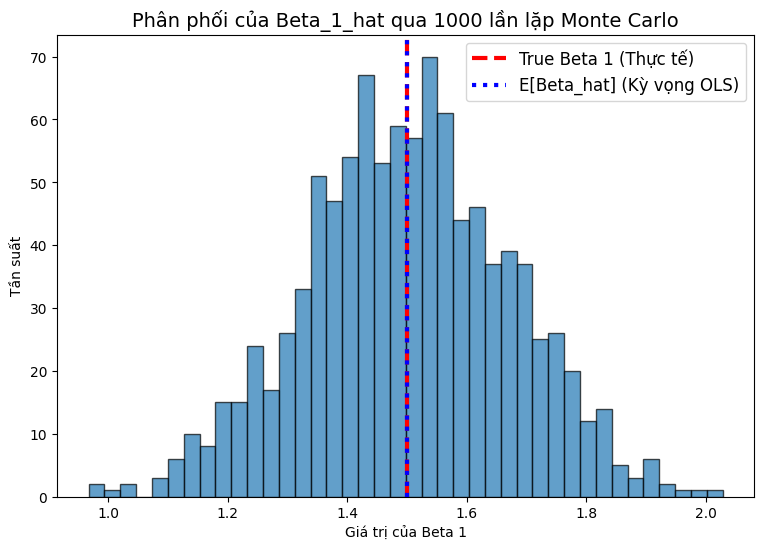

In [5]:
# Mô phỏng Monte Carlo 1000 lần
n_sims = 1000
betas_sim = []

for _ in range(n_sims):
    # Lấy mẫu y mới do sai số ngẫu nhiên thay đổi
    y_sim = X_int @ true_beta + np.random.randn(n, 1) * 1.5
    b_hat, _ = ols_fit(X, y_sim)
    betas_sim.append(b_hat.flatten())

betas_sim = np.array(betas_sim)
mean_betas = np.mean(betas_sim, axis=0)

print("Kỳ vọng thực sự của Beta (True Beta):  ", true_beta.flatten())
print("Trung bình Beta_hat (1000 lần MC):    ", mean_betas)

# Vẽ biểu đồ Histogram cho hệ số Feature 1 (beta_1)
plt.figure(figsize=(9, 6))
plt.hist(betas_sim[:, 1], bins=40, edgecolor='black', alpha=0.7)
plt.axvline(true_beta[1][0], color='red', linestyle='dashed', linewidth=3, label='True Beta 1 (Thực tế)')
plt.axvline(mean_betas[1], color='blue', linestyle='dotted', linewidth=3, label='E[Beta_hat] (Kỳ vọng OLS)')
plt.title("Phân phối của Beta_1_hat qua 1000 lần lặp Monte Carlo", fontsize=14)
plt.xlabel("Giá trị của Beta 1")
plt.ylabel("Tần suất")
plt.legend(fontsize=12)
plt.show()